In [1]:
### This notebook does expression data processing

In [2]:
# Requirements

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
import shap
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import shapiro
from scipy.stats import pearsonr
import gc
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import zscore
import math
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import RandomizedSearchCV
plt.rcParams['pdf.fonttype']=42
import allel

/Users/madisoncreach/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# print versions of packages

print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

pandas==2.2.1
seaborn==0.13.2
numpy==1.26.4
xgboost==2.0.3
shap==0.45.1
allel==1.3.13


In [4]:
# Read in expression data files

path = ('/Users/madisoncreach/Prediction_Project/merged_gene_tpms_2021MSU_contaminated_free.csv')
MI_exp = pd.read_csv(path, header=0)
print(MI_exp.shape)

path2 = ('/Users/madisoncreach/Prediction_Project/merged_gene_tpms_longestT.csv')
NE_exp = pd.read_csv(path2, header=0)
print(NE_exp.shape)

(44303, 726)
(39756, 751)


In [5]:
## Start of filtering steps

In [6]:
# make sure Gene ID is set as index
MI_exp = MI_exp.set_index('GeneID')

NE_exp = NE_exp.set_index('GeneID')

In [7]:
# drop all N/A and check df shape

MI_exp = MI_exp.dropna()

NE_exp = NE_exp.dropna()

print(MI_exp.shape)
print(NE_exp.shape)

(44303, 725)
(39756, 750)


In [8]:
# filter out rows where the standard deviation is zero and check df shape

row_std = MI_exp.std(axis=1)
MI_filtered_exp = MI_exp[row_std != 0]

row_std = NE_exp.std(axis=1)
NE_filtered_exp = NE_exp[row_std != 0]

print(MI_filtered_exp.shape)
print(NE_filtered_exp.shape)

(43019, 725)
(38736, 750)


In [9]:
## Filter out non-expressed genes

MI_filtered_exp = MI_filtered_exp.loc[MI_filtered_exp.sum(axis=1) > 10, :]

NE_filtered_exp = NE_filtered_exp.loc[NE_filtered_exp.sum(axis=1) > 10, :]

## Filter out lowly expressed genes

mask_low_vals = (MI_filtered_exp > 1).sum(axis=1) > 10
MI_filtered_exp = MI_filtered_exp.loc[mask_low_vals, :]

mask_low_vals2 = (NE_filtered_exp > 1).sum(axis=1) > 10
NE_filtered_exp = NE_filtered_exp.loc[mask_low_vals2, :]

# check shape of dfs

print(MI_filtered_exp.shape)
print(NE_filtered_exp.shape)

(33778, 725)
(30302, 750)


In [10]:
## Filtering steps finished

In [11]:
## Merge the two datasets into one

full_exp = pd.merge(MI_filtered_exp, NE_filtered_exp, on="GeneID")
print(full_exp.shape)

(28221, 1475)


In [12]:
###### LOG TRANSFORM THE DATA FUNCTION

def log_transform(df):
    log_df = df.copy() 
    
    for c in [c for c in log_df.columns if np.issubdtype(log_df[c].dtype , np.number)]:
        log_df[c] += 1
    for c in [c for c in log_df.columns if np.issubdtype(log_df[c].dtype , np.number)]:
        log_df[c] = np.log(log_df[c])
    return log_df

In [13]:
## Start of code to run first a log transformation, then perform batch correction, then plot a PCA

In [14]:
# log transform the datasets

log_expr_df = log_transform(full_exp)
log_expr_df.head()

,3001_Oh40B,3002_PHHH9,3003_Sg_1533,3004_R78,3005_H84,3006_PHK35,3007_H49,3008_CI_21E,3009_A634,3010_B68,...,WXB6,Wf9,YE-CHI-HUNG,YE_4,YING-55,YONG28,YU796NS,ZS01250,ZS1791,ZS635
GeneID,,,,,,,,,,,,,,,,,,,,,
Zm00001eb000010,3.120742,2.666534,2.928433,3.445157,2.755265,2.922635,2.975948,2.818124,2.252008,2.452478,...,3.128211,2.965855,2.783288,3.066522,3.389688,3.324450,2.990453,4.139084,3.361725,2.719392
Zm00001eb000020,0.415559,0.332283,0.401518,1.082225,0.309681,0.370421,0.425613,0.342172,0.506318,0.311885,...,1.408819,1.071200,1.145900,1.623339,0.975827,1.533664,0.833904,1.227351,1.080238,0.672318
Zm00001eb000060,4.372334,4.113220,2.653988,5.289201,2.302134,3.636641,4.560308,3.724329,4.033330,3.980580,...,3.513326,3.784896,3.428381,3.971127,3.994631,2.244984,3.375558,4.561682,3.616126,3.681923
Zm00001eb000070,1.660386,1.814719,2.143157,0.184052,2.134789,1.902137,1.094213,0.955765,0.587116,0.025353,...,2.947597,0.000000,0.000000,0.298965,0.000000,0.000000,0.000000,2.243346,1.765056,2.105333
Zm00001eb000080,3.903380,3.278340,3.870882,4.476615,3.274261,1.246708,3.369063,4.021577,3.393558,3.558449,...,3.919068,3.600179,0.418160,0.063221,4.087714,3.596123,0.081676,4.682742,3.492807,3.850558


In [15]:
# get list of labels for batch correction and PCA visualization

cols = []
labels=[]
for i in MI_filtered_exp.columns:
    cols.append(i)
    labels.append("MI")
for n in NE_filtered_exp.columns:
    cols.append(n)
    labels.append("NE")
state_dict = dict(zip(cols, labels))

label_color_dict = {'MI':'red',"NE":'blue'}
cvec = [label_color_dict[label] for label in labels]

In [16]:
# run batch correction on log corrected data

from combat.pycombat import pycombat

batch_corrected_data = pycombat(log_expr_df, labels)

Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


In [17]:
# look at corrected data

print(batch_corrected_data)

                 3001_Oh40B  3002_PHHH9  3003_Sg_1533  3004_R78  3005_H84  \
GeneID                                                                      
Zm00001eb000010    3.230994    2.734073      3.020600  3.585914  2.831148   
Zm00001eb000020    0.707997    0.631146      0.695040  1.323236  0.610287   
Zm00001eb000060    4.010590    3.786349      2.523504  4.804063  2.219003   
Zm00001eb000070    1.561777    1.723188      2.066687  0.017740  2.057936   
Zm00001eb000080    4.015285    3.377359      3.982118  4.600340  3.373196   
...                     ...         ...           ...       ...       ...   
Zm00001eb442830    0.003725    0.003725      0.003725  0.003725  0.003725   
Zm00001eb442890    0.019405    0.019405      0.019405  0.140431  0.019405   
Zm00001eb442940    0.606187    1.179078      0.463762  0.187294  0.176668   
Zm00001eb442990    1.597341    0.655974      2.376273  0.092138  0.141570   
Zm00001eb443030    1.399632   -0.137174      1.747615 -0.137172  2.398936   

In [18]:
# run PCA on both Nebraska and Michigan data

features_l2b_transposed = batch_corrected_data.T
print(features_l2b_transposed)

pca_l2b = PCA(n_components=2)
print(pca_l2b)
principal_components_l2b = pca_l2b.fit_transform(features_l2b_transposed)

GeneID        Zm00001eb000010  Zm00001eb000020  Zm00001eb000060  \
3001_Oh40B           3.230994         0.707997         4.010590   
3002_PHHH9           2.734073         0.631146         3.786349   
3003_Sg_1533         3.020600         0.695040         2.523504   
3004_R78             3.585914         1.323236         4.804063   
3005_H84             2.831148         0.610287         2.219003   
...                       ...              ...              ...   
YONG28               3.220316         1.190213         2.689921   
YU796NS              2.909998         0.612435         3.635411   
ZS01250              3.977196         0.937296         4.627357   
ZS1791               3.254948         0.815827         3.836596   
ZS635                2.658154         0.479016         3.891621   

GeneID        Zm00001eb000070  Zm00001eb000080  Zm00001eb000120  \
3001_Oh40B           1.561777         4.015285         1.125516   
3002_PHHH9           1.723188         3.377359         1.3212

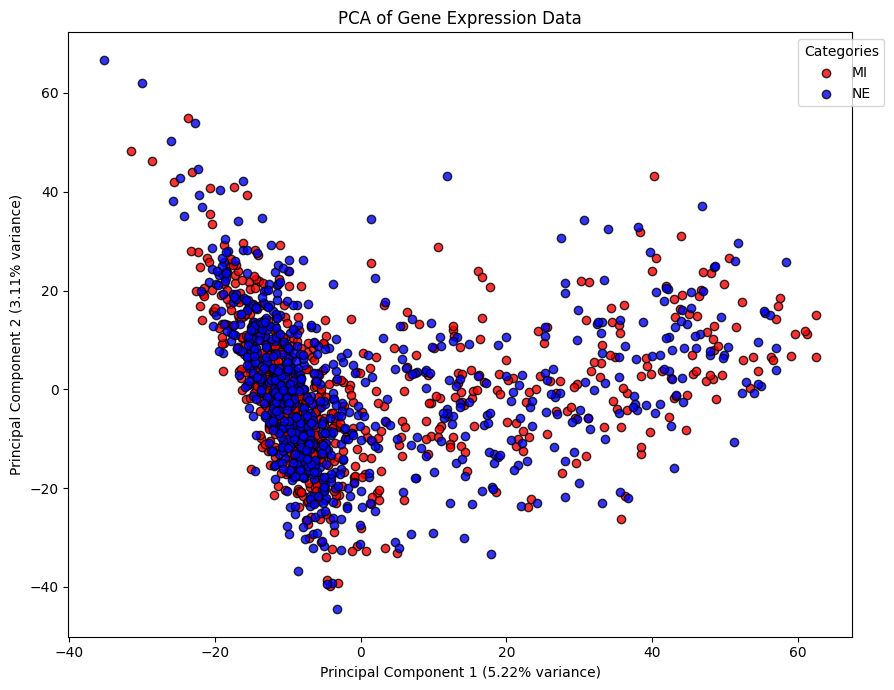

In [19]:
# create a PCA with a legend

var_exp = pca_l2b.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))
for label, color in label_color_dict.items():
    indices = [i for i, lbl in enumerate(labels) if lbl == label]
    plt.scatter(principal_components_l2b[indices, 0], principal_components_l2b[indices, 1],
                c=color, edgecolors='k', label=label, alpha=0.8)

# Add title and labels
plt.title('PCA of Gene Expression Data')
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.2f}% variance)')

# Add legend
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), title='Categories')


# Adjust layout to fit legend
plt.tight_layout()

# Show the plot
plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig2_A.pdf")

In [20]:
# get the explained variance for this pca

print(pca_l2b.explained_variance_ratio_)

[0.05223156 0.03108676]


In [21]:
#define all subpopulations
Broad_origin_public=["779", "4226", "33-16", "38-11", "A", "A12", "A15", "A155", "A171", "A188",
    "A208", "A239", "A258", "A305", "A321", "A322", "A334", "A340", "A344", "A374",
    "A385", "A401", "A508", "A548", "A554", "A556", "A572", "A627", "A648", "A649",
    "A651", "A654", "A659", "A661", "A662", "A673", "A71", "A73", "A797NW", "A96",
    "AH83", "B112", "B118", "B120", "B121", "B164", "B2", "B42", "B52", "B54", "B57",
    "B7", "B76", "B8", "B85", "B90", "B97", "B99", "Bei 10 = North 10", "C49A", "CG10",
    "CG108", "CH157", "CH701-30", "CH9", "Chi-tan 120", "CI 187-2", "CI 28A", "CI 3A",
    "CI 40H", "CI 82B", "CM37", "CMV3", "CO106", "CO117", "CO125", "CO158", "CO192",
    "CO216", "CO236", "CO237", "CR 22 INBRED", "CSJ3", "EAST 028", "Eng-Li Chih", "F115",
    "GE129", "H5", "H52", "H71", "INBRED 141", "K148", "K150", "K155", "K201", "K4", "K41",
    "Ky21", "Ky228", "L317", "LH85", "M14", "Mo13", "Mo15W", "Mo23W", "Mo24W", "Mo3", "Mo44",
    "MS106", "MS116", "MS12", "MS1334", "MS142", "MS153", "MS200", "MS211", "MS223", "MS224",
    "MS24A", "MS67", "MS71", "MS72", "Mt42", "N193", "N199", "N200", "N6", "NC260", "ND167",
    "ND230", "ND245", "ND246", "ND247", "ND249", "ND251", "ND259", "ND260", "ND262", "ND265",
    "ND283", "ND287", "Oh33", "Os426", "Pa392", "Pa405", "Pa468", "PHT73", "R101", "R113",
    "R134", "R168", "R177", "R181B", "R30", "R4", "R53", "R71", "R78", "RS 710", "SD42", "T141",
    "T234", "W10001_0003", "W10001_0007", "W10001_0009", "W10001_0010", "W10001_0012",
    "W10001_0016", "W10001_0018", "W10001_0030", "W10001_0031", "W10001_0040", "W10002_0001",
    "W10002_0004", "W117HT", "W153R", "W182B", "W182BN", "W182E", "W22", "W23", "W24", "W32",
    "W37A", "W552", "W59E", "W9", "WD", "WR3", "YING-55"]
IDT=["904", "911", "912", "1538", "11430", "AM0776", "B107", "B114", "DE1", "DE2", "DK29MIBZ2",
    "DK3IIH6", "DK3IJI1", "DK83IBI3", "DK91IFC2", "DKIB014", "DKIB02", "DKIBB14", "DKIBB15",
    "DKIBC2", "DKLIBC 4", "DKMBWZ", "DKMBZA", "ICI 986", "L 127", "L 135", "L 155", "LH164",
    "MQ305", "NKNP899", "NQ402", "NQ508", "NS501", "OQ403", "OQ601", "OQ603", "OS602", "PH207",
    "PHAW6", "PHG29", "PHG50", "PHG72", "PHG83", "PHGW7", "PHH93", "PHJ75", "PHJ90", "PHK42",
    "PHK74", "PHKE6", "PHM10", "PHN11", "PHN47", "PHN82", "PHP02", "PHP55", "PHP76", "PHR25",
    "PHR31", "PHR63", "PHT22", "PHTD5", "PHV57", "PHVJ4", "PHW06", "PHW53", "PHW86", "SD102", "L_135", "L_127", "ICI_986", "L_155", "DKLIBC_4",
    "29MIBZ2", "91IFC2", "AM0776_R2", "IBB15", "LIBC_4", "MBWZ"]
Mixed=["787", "52220", "07108Vbt", "4578 INBRED", "4F-234 BX 4", "A415-1-3 INBRED", "A427",
    "A441-5", "A663", "A674", "AR228", "AS5707", "AusTRCF 306238", "B106", "B108", "B113",
    "B115", "B75", "B77", "B79", "B87", "B88", "B91", "B98", "C102", "C123", "CG106", "CG65",
    "CH711-10", "CI 21E", "CI 31A", "CI 90C", "CI 91B", "CM48", "CS405", "CS608", "DE4",
    "DK2MA22", "DK3IBZ2", "DK4676A", "DK6F629", "DK6M502", "DK6M502A", "DK8M116", "DK8M129",
    "DKHBA1", "DKMBPM", "E2558W", "F431", "F44", "Fe", "FR19", "GE54", "H110", "H113", "H121",
    "H124w", "H14", "H96", "H99", "Hi26", "I11.12E", "I205", "ICI 193", "INBRED 321", "J47",
    "J8606", "K55", "K64", "KO679Y", "KUNG-70", "Ky226", "L 289", "L222", "LE23", "LH150",
    "LH160", "LH162", "LH163", "LH172", "LH175", "LH184", "LH191", "LH299", "LH82", "LH93",
    "M162W", "M37W", "MEF156-55-2", "Mo16W", "Mo1W", "Mo28W", "Mo30W", "Mo39", "Mo45", "Mo46",
    "Mo47", "Mo5", "MoG", "Mp339", "MS132", "MS225", "MS226", "N211", "N215", "N216", "N534",
    "NC13", "NC230", "NC232", "NC236", "NC318", "NC342", "NC412", "NC472", "ND101", "NK907",
    "NKH8431", "NORTH 7", "NY 159 (Neveh Yaar)", "NY 166 (Neveh Yaar)", "Ny821", "OC19",
    "Oh1EP", "Oh3167B", "Oh603", "Oh7", "Oh7B", "OQ101", "Os420", "Pa778", "Pa880", "PH5HK",
    "PHEG9", "PHFA5", "PHG35", "PHG84", "PHG86", "PHGV6", "PHHB9", "PHHH9", "PHJ31", "PHJ33",
    "PHJ65", "PHJ70", "PHK05", "PHK46", "PHKM5", "PHM57", "PHM81", "PHMK0", "PHN34", "PHN66",
    "PHP60", "PHPR5", "PHR03", "PHR32", "PHR36", "PHR55", "PHR62", "PHV78", "PHW03", "PHW20",
    "PHW30", "PHW79", "PHZ51", "R197", "R225", "R226", "SD15", "SD40", "SD44", "T232", "Tx303",
    "TZU-CHIAO-HSI-WU 105", "U267Y", "Va14", "Va17", "Va22", "Va38", "Va52", "Va85", "Va99",
    "VaW6", "W602S", "W603S", "W64A", "W703", "W802G", "W810G", "W814G", "W815G", "W816G",
    "W818G", "WD456", "WU-TAN-TZAO", "WXB6", "Yong 28", "Yu796 NS", "ZS01250", "ZS635"]
NSS_Mo17=["A682", "B70", "C103", "CR1HT", "DKMBNA", "E8501", "LH128", "LH165", "LH167", "LH181", 
    "LH183", "LH185", "LH186", "LH188", "LH189Ht", "LH210", "LH211", "LH215", "LH216", "LH217", 
    "LH218", "LH252", "LH260", "LH51", "LH52", "LH54", "LH57", "LH59", "LH60", "LH61", "Lp215D", 
    "Mo17", "N197", "NK740", "NKBCC03", "S8326", "Seagull Seventeen", "W601S", "W604S", "W605S", 
    "WIL900", "WIL901", "WIL903", "CI_21E", "AusTRCF_30", "CI_187-2", "Seagull_Se","CI_91B_Goo", "DKMB", "CI_64", "AusTRCF_306238",
    "B97_R2", "CI_3A", "CI_91B", "LH128_R2", "MBPM", "MBST", "N193_R2", "Seagull_Seventeen"]
NSS_Oh43=["A619", "B65", "B66", "CQ702RC", "CQ806", "DE3", "DK2MCDB", "DK78371A", "DK78551S", 
    "DKMBST", "DKMBUB", "DKMDF-13D", "DKMM402A", "DKMM501D", "H49", "H95", "ICI 581", 
    "L 139", "LH123HT", "LH127", "LH156", "LH166", "LH169Ht", "LH212Ht", "LH213", "LH214", 
    "LH250", "LH284", "LH38", "LH39", "ML606", "Oh40B", "Oh43", "Oh43E", "Pa762", "Pa891", 
    "Pa91", "PHBA6", "PHG47", "PHJ89", "PHK56", "PHK76", "PHK93", "PHM49", "PHN46", "PHN73", 
    "PHR58", "PHT60", "PHT77", "PHTM9", "PHV53", "PHW43", "PHW65", "PHW80", "PHWG5", "Va26", 
    "W817G", "W821G", "Wf9", "L_289", "ICI_581", "L_139", "2MA22", "2MCDB", "6M502", "6M502A", "78551S", "CO125_R2",
    "DKMFD-13D", "Hy", "IBC2", "LH127_R2", "MEF156-55-2_R2", "MM501D", "PHK76_R2", "Pa762_R2", "Va14_R2", "W182B_R2", "W182E_R2", "W802G_R2"]
Popcorn=["4722", "B-18 INBR.FR.SUPERGOLD", "B-28", "CI 64", "HP301", "HP72-11", "I29", "IDS28", "IDS69",
    "IDS91", "K47", "Mo7", "NC258", "NC262", "NC290A", "NC344", "NC362", "NC364", "NP87", "Sg 1533",
    "Sg 18", "SG 30A", "T8", "Va102", "Va35", "Va59", "Sg_1533", "B-18_INBR_", "Sg_18", "SG_30A", "B-18_INBR.FR.SUPERGOLD",
    "B-18_INBR.FR.SUPERGOLD_R2", "HP301_R2"]
SS_B14=["A632", "A634", "A635", "A641", "A672", "AS6103", "B14", "B14A", "B64", "B68", "CH753-4", 
    "CM105", "CM7", "CM99", "DE811", "DKAQA3", "DKFBHJ", "DKFBLA", "DKHB8229", "H105W", "H91", 
    "INB 101LFY/LFY (A632 X M16 S5)", "LH143 (Maintainer)", "LH143 CMS", "LH145", "LH146Ht", 
    "LH220Ht", "LH222", "LH223", "LH224", "LH225", "LP1 NR Ht", "N217", "N218", "PHG71", "PHW51", 
    "SD107", "W813G", "INB_101LFY", "LP1_NR_Ht", "AQA3", "HB8229", "LH143_(Maintainer)", "LH222_R2"]
SS_B37=["B37", "DK84BRQ4", "DK84QAB1", "DKF274", "H114", "H84", "LH1", "MS221", "MS222", "NC250", 
    "NC314", "NC324", "NK807", "PHAA0", "PHB09", "PHB47", "PHBB3", "PHBW8", "PHEM9", "PHEW7", 
    "PHG39", "PHG80", "PHHB4", "PHJ40", "PHJR5", "PHK29", "PHK35", "PHN18", "PHN41", "PHP38", 
    "PHP85", "PHR61", "PHRE1", "PHT11", "PHT47", "PHT55", "PHT69", "PHTE4", "PHV07", "PHV37", 
    "PHV63", "PHVA9", "PHW52", "PHWRZ", "SD101", "NC250_R2", "PHEM9_R2", "PHEW7_R2", "PHJ40_R2", "PHK29_R2", "PHK35_R2",
    "PHRE1_R2"]
SS_B73=["764", "790", "793", "2369", "4N506", "A679", "A680", "B109", "B73", "B73Htrhm", "CR14",
    "DJ7", "DK2FACC", "DK2FADB", "DK6F545", "DK78002A", "DK78004", "DK78010", "DK87916W",
    "DK8F196", "DKF118", "DKFBLL", "DKNL001", "DKPB80", "DKWDAD1", "F42", "H122w", "ICI 441",
    "ICI 740", "ICI 893", "LH119", "LH132", "LH149", "LH159", "LH190", "LH192", "LH193", "LH194",
    "LH195", "LH196", "LH197", "LH198", "LH199", "LH200", "LH202", "LH204", "LH205", "LH206",
    "LH208", "LH209", "LH231", "LH74", "LP5", "N192", "N201", "NC294", "NC306", "NC310", "NC326",
    "NC328", "NC368", "NK792", "NK794", "NKNP901", "NS701", "PHT10", "PHW17", "R229", "S8324",
    "W809G", "W811G", "W812G", "W819G", "W820G", "W8304", "W8555", "ZS1791", "78004", "ICI_893", "LH143__Mai", "ICI_740", "ICI_441",
    "2FACC", "2FADB", "87916W", "DK78002A_R2", "F118", "FBLA", "FBLA_R2", "FBLL", "ICI_893_R2", "LH204_R2", "LH74_R2", "N201_R2", "W813G_R2"]
SS_BSSSC0=["B10", "B101", "B104", "B105", "B110", "B111", "B119", "B46", "B84", "BSSSC0_001", "BSSSC0_002",
    "BSSSC0_003", "BSSSC0_005", "BSSSC0_006", "BSSSC0_007", "BSSSC0_008", "BSSSC0_009", "BSSSC0_012",
    "BSSSC0_013", "BSSSC0_014", "BSSSC0_015", "BSSSC0_016", "BSSSC0_018", "BSSSC0_019", "BSSSC0_020",
    "BSSSC0_021", "BSSSC0_022", "BSSSC0_023", "BSSSC0_024", "BSSSC0_025", "BSSSC0_026", "BSSSC0_028",
    "BSSSC0_029", "BSSSC0_030", "BSSSC0_031", "BSSSC0_033", "BSSSC0_034", "BSSSC0_035", "BSSSC0_036",
    "BSSSC0_037", "BSSSC0_038", "BSSSC0_039", "BSSSC0_040", "BSSSC0_041", "BSSSC0_042", "BSSSC0_043",
    "BSSSC0_044", "BSSSC0_045", "BSSSC0_046", "BSSSC0_048", "BSSSC0_049", "BSSSC0_050", "BSSSC0_051",
    "BSSSC0_052", "BSSSC0_053", "BSSSC0_054", "BSSSC0_055", "BSSSC0_056", "BSSSC0_057", "BSSSC0_058",
    "BSSSC0_060", "BSSSC0_061", "BSSSC0_062", "CI 540", "CO256", "CO257", "CO258", "I159", "I224", "Ill.Hy",
    "N209", "N28", "N28E", "N28Ht", "N501", "N523", "N527", "N538", "N540", "N542", "N545", "N7A", "R227",
    "Tr", "Tr9-1-1-6", "B101_R2", "B105_R2", "N527_R2"]
Sweet_corn=["04033V", "4554 INBRED", "80-2", "C15", "C42", "C68", "CA-4", "CL17", "CL18", "CL22", "CL27",
    "CO245", "CO255", "EP1", "F2", "F7", "FC46", "G22 T122", "G3 T5a", "IA2132", "Ia453", "Ia5125B",
    "Il 101T", "Il14H", "Il778d", "ND1", "NO. 380", "P39", "PHDD6", "PHEM7", "PHGG7", "S 56", "T146",
    "T242", "T9", "U 123", "W7151", "W85", "Il_101T", "C15_R2", "CO255_R2"]
Tropical=["4F-306 108", "4F-35 BK", "4F-403 JV 15", "A3G-3-3-1-313", "CML 108", "CML 144", "CML 154Q", 
    "CML 161", "CML 176", "CML 197", "CML 202", "CML 216", "CML 218", "CML 220", "CML 228", 
    "CML 247", "CML 251", "CML 254", "CML 264", "CML 277", "CML 287", "CML 312", "CML 322", 
    "CML 323", "CML 376", "CML 387", "CML 395", "CML 421", "CML 444", "CML 448", "CML 451", 
    "CML 465", "CML 488", "CML 491", "CML 496", "CML 504", "CML 505", "CML 509", "CML 511", 
    "CML 52", "CML 91", "F2834T", "Hi28", "Huanyao", "Huobai", "INBRED 100", "INBRED 109", 
    "INBRED 2-687", "INBRED 305", "INBRED 309", "Ki11", "Ki21", "Ki3", "Ki43", "Mo18W", "NC264", 
    "NC298", "NC302", "NC304", "NC338", "NC340", "NC348", "NC350", "NC356", "NC358", "NY6371", 
    "W803G", "WIL500", "YANG", "YE 4", "YE-CHI-HUNG", "YELLOW 3-4", "CML_91", "CML_218", "INBRED_321", "INBRED_109",
    "CML_220", "CML_108", "CML_323", "CML_228", "INBRED_2-6", "A415-1-3_I", "YE_4", "CML_322", "A415-1-3_INBRED",
    "A797NW_R2", "CML_322_R2", "CML_395", "Huobai_R2", "INBRED_2-687", "NC356_R2", "NY6371_R2"]
Unclassified=["A3G-3-3-1-", "INBRED_305", "Yu796_NS", "4F-306_108", "CML_154Q", "S_56", "INBRED_141", "RS_710", "Eng-Li_Chi",
"YE-CHI-HUN", "Yong_28", "4578_INBRE", "YELLOW_3-4", "NORTH_7", "Bei_10___N", "TZU-CHIAO-", "Chi-tan_12", "INBRED_309",
"CI_40H", "ICI_193", "WU-TAN-TZA", "CI_28A", "CI_540", "INBRED_100", "NY_159__Ne", "NY_166__Ne", "NO__380", "Ill_Hy",
"4554_INBRED", "4578_INBRED", "4F-306_108_R2", "A663_R2", "Bei_10_=_North_10", "CG10_R2", "Chi-tan_120", "Chi-tan_120_R2",
"DK8M116_R2", "Eng-Li_Chih", "GE129_R2", "Mo16W_R2", "N534_R2", "NP899", "NP899_R2", "NY_166_(Neveh_Yaar)", "PHHH9_R2", "PHMK0_R2",
"TZU-CHIAO-HSI-WU_105", "YONG28", "YU796NS", "INB_101LFY_LFY__A632_X_M16_S5_"]
Flint=["G3_T5a", "U_123", "G22_T122", "NO._380"]

In [22]:
 #create a dictionary to color the above PCA by subpopulation

widiv_cols = []
widiv_labels=[]
uncategorized=[]

for i in MI_filtered_exp.columns:
    new_i = i[5:]
    if new_i in Broad_origin_public:
        widiv_cols.append(new_i)
        widiv_labels.append("Broad_origin_public")
    if new_i in IDT:
        widiv_cols.append(new_i)
        widiv_labels.append("IDT")
    if new_i in Mixed:
        widiv_cols.append(new_i)
        widiv_labels.append("Mixed")
    if new_i in NSS_Mo17:
        widiv_cols.append(new_i)
        widiv_labels.append("NSS_Mo17")
    if new_i in NSS_Oh43:
        widiv_cols.append(new_i)
        widiv_labels.append("NSS_Oh43")
    if new_i in Popcorn:
        widiv_cols.append(new_i)
        widiv_labels.append("Popcorn")
    if new_i in SS_B14:
        widiv_cols.append(new_i)
        widiv_labels.append("SS_B14")
    if new_i in SS_B37:
        widiv_cols.append(new_i)
        widiv_labels.append("SS_B37")
    if new_i in SS_B73:
        widiv_cols.append(new_i)
        widiv_labels.append("SS_B73")
    if new_i in SS_BSSSC0:
        widiv_cols.append(new_i)
        widiv_labels.append("SS_BSSSC0")
    if new_i in Sweet_corn:
        widiv_cols.append(new_i)
        widiv_labels.append("Sweet_corn")
    if new_i in Tropical:
        widiv_cols.append(new_i)
        widiv_labels.append("Tropical")
    if new_i in Unclassified:
        widiv_cols.append(new_i)
        widiv_labels.append("Unclassified")
    if new_i in Flint:
        widiv_cols.append(new_i)
        widiv_labels.append("Flint")
    if new_i not in Broad_origin_public and new_i not in IDT and new_i not in Mixed and new_i not in NSS_Mo17 and new_i not in NSS_Oh43 and new_i not in Popcorn and new_i not in SS_B14 and new_i not in SS_B37 and new_i not in SS_B73 and new_i not in SS_BSSSC0 and new_i not in Sweet_corn and new_i not in Tropical and new_i not in Unclassified and new_i not in Flint:
        uncategorized.append(new_i)
    

for n in NE_filtered_exp.columns:
    if n in Broad_origin_public:
        widiv_cols.append(n)
        widiv_labels.append("Broad_origin_public")
    if n in IDT:
        widiv_cols.append(n)
        widiv_labels.append("IDT")
    if n in Mixed:
        widiv_cols.append(n)
        widiv_labels.append("Mixed")
    if n in NSS_Mo17:
        widiv_cols.append(n)
        widiv_labels.append("NSS_Mo17")
    if n in NSS_Oh43:
        widiv_cols.append(n)
        widiv_labels.append("NSS_Oh43")
    if n in Popcorn:
        widiv_cols.append(n)
        widiv_labels.append("Popcorn")
    if n in SS_B14:
        widiv_cols.append(n)
        widiv_labels.append("SS_B14")
    if n in SS_B37:
        widiv_cols.append(n)
        widiv_labels.append("SS_B37")
    if n in SS_B73:
        widiv_cols.append(n)
        widiv_labels.append("SS_B73")
    if n in SS_BSSSC0:
        widiv_cols.append(n)
        widiv_labels.append("SS_BSSSC0")
    if n in Sweet_corn:
        widiv_cols.append(n)
        widiv_labels.append("Sweet_corn")
    if n in Tropical:
        widiv_cols.append(n)
        widiv_labels.append("Tropical")
    if n in Unclassified:
        widiv_cols.append(n)
        widiv_labels.append("Unclassified")
    if n in Flint:
        widiv_cols.append(n)
        widiv_labels.append("Flint")
    if n not in Broad_origin_public and n not in IDT and n not in Mixed and n not in NSS_Mo17 and n not in NSS_Oh43 and n not in Popcorn and n not in SS_B14 and n not in SS_B37 and n not in SS_B73 and n not in SS_BSSSC0 and n not in Sweet_corn and n not in Tropical and n not in Unclassified and n not in Flint:
        uncategorized.append(n)
    
print(len(widiv_cols))


widiv_dict = dict(zip(widiv_cols, widiv_labels))

widiv_label_color_dict = {'Broad_origin_public':'#0072B2',"IDT":'#E69F00', "Mixed":'#56B4E9',"NSS_Mo17":'#009E73',"NSS_Oh43":'#F0E442',"Popcorn":'#D55E00',"SS_B14":'#CC79A7',"SS_B37":'#89CFF0',"SS_B73":'#228B22',"SS_BSSSC0":'#FF4500',"Sweet_corn":'#008080',"Tropical":'#8B4513',"Unclassified":'#FF69B4',"Flint":'#808080'}
widiv_cvec = [widiv_label_color_dict[label] for label in widiv_labels]

1475


In [23]:
print(widiv_dict)

{'Oh40B': 'NSS_Oh43', 'PHHH9': 'Mixed', 'Sg_1533': 'Popcorn', 'R78': 'Broad_origin_public', 'H84': 'SS_B37', 'PHK35': 'SS_B37', 'H49': 'NSS_Oh43', 'CI_21E': 'NSS_Mo17', 'A634': 'SS_B14', 'B68': 'SS_B14', 'NC350': 'Tropical', 'W815G': 'Mixed', 'NY_159__Ne': 'Unclassified', 'LH208': 'SS_B73', 'LH217': 'NSS_Mo17', 'T146': 'Sweet_corn', 'N217': 'SS_B14', 'LH52': 'NSS_Mo17', 'N218': 'SS_B14', 'LH166': 'NSS_Oh43', 'N545': 'SS_BSSSC0', 'PHW65': 'NSS_Oh43', 'LH209': 'SS_B73', 'CO256': 'SS_BSSSC0', 'PHK05': 'Mixed', 'DK91IFC2': 'IDT', 'A15': 'Broad_origin_public', 'Pa468': 'Broad_origin_public', 'W811G': 'SS_B73', 'NY_166__Ne': 'Unclassified', 'LH184': 'Mixed', 'PHWRZ': 'SS_B37', 'A3G-3-3-1-': 'Unclassified', 'CML_91': 'Tropical', 'B85': 'Broad_origin_public', 'R134': 'Broad_origin_public', 'MoG': 'Mixed', 'LH215': 'NSS_Mo17', 'B91': 'Mixed', 'CO158': 'Broad_origin_public', 'AM0776': 'IDT', 'C123': 'Mixed', 'N527': 'SS_BSSSC0', 'A661': 'Broad_origin_public', 'DK78010': 'SS_B73', 'A572': 'Broad_

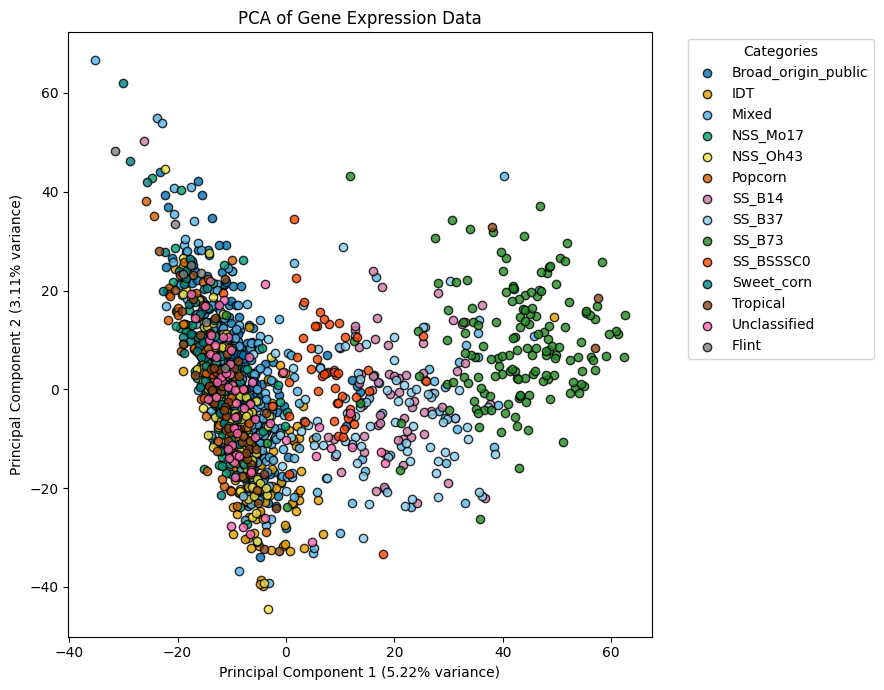

In [24]:
# create a PCA with a legend

var_exp = pca_l2b.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))
for label, color in widiv_label_color_dict.items():
    indices = [i for i, lbl in enumerate(widiv_labels) if lbl == label]
    plt.scatter(principal_components_l2b[indices, 0], principal_components_l2b[indices, 1],
                c=color, edgecolors='k', label=label, alpha=0.8)

# Add title and labels
plt.title('PCA of Gene Expression Data')
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.2f}% variance)')

# Add legend
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), title='Categories')


# Adjust layout to fit legend
plt.tight_layout()

# Show the plot
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig1_A.pdf")

In [25]:
## End of code to run a log transformation, then perform batch correction, then plot a PCA

In [26]:
# Now read in genetic data and plot a PCA

In [27]:
 #create a dictionary to color the GENETIC PCA by subpopulation

widiv_cols_gen = []
widiv_labels_gen=[]
uncategorized_gen=[]

for i in MI_filtered_exp.columns:
    new_i = i[5:]
    if new_i in Broad_origin_public:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Broad_origin_public")
    if new_i in IDT:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("IDT")
    if new_i in Mixed:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Mixed")
    if new_i in NSS_Mo17:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("NSS_Mo17")
    if new_i in NSS_Oh43:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("NSS_Oh43")
    if new_i in Popcorn:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Popcorn")
    if new_i in SS_B14:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("SS_B14")
    if new_i in SS_B37:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("SS_B37")
    if new_i in SS_B73:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("SS_B73")
    if new_i in SS_BSSSC0:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("SS_BSSSC0")
    if new_i in Sweet_corn:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Sweet_corn")
    if new_i in Tropical:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Tropical")
    if new_i in Unclassified:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Unclassified")
    if new_i in Flint:
        widiv_cols_gen.append(new_i + "_" + new_i)
        widiv_labels_gen.append("Flint")
    if new_i not in Broad_origin_public and new_i not in IDT and new_i not in Mixed and new_i not in NSS_Mo17 and new_i not in NSS_Oh43 and new_i not in Popcorn and new_i not in SS_B14 and new_i not in SS_B37 and new_i not in SS_B73 and new_i not in SS_BSSSC0 and new_i not in Sweet_corn and new_i not in Tropical and new_i not in Unclassified and new_i not in Flint:
        uncategorized_gen.append(new_i)
    

for n in NE_filtered_exp.columns:
    if n in Broad_origin_public:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Broad_origin_public")
    if n in IDT:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("IDT")
    if n in Mixed:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Mixed")
    if n in NSS_Mo17:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("NSS_Mo17")
    if n in NSS_Oh43:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("NSS_Oh43")
    if n in Popcorn:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Popcorn")
    if n in SS_B14:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("SS_B14")
    if n in SS_B37:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("SS_B37")
    if n in SS_B73:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("SS_B73")
    if n in SS_BSSSC0:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("SS_BSSSC0")
    if n in Sweet_corn:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Sweet_corn")
    if n in Tropical:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Tropical")
    if n in Unclassified:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Unclassified")
    if n in Flint:
        widiv_cols_gen.append(n + "_" + n)
        widiv_labels_gen.append("Flint")
    if n not in Broad_origin_public and n not in IDT and n not in Mixed and n not in NSS_Mo17 and n not in NSS_Oh43 and n not in Popcorn and n not in SS_B14 and n not in SS_B37 and n not in SS_B73 and n not in SS_BSSSC0 and n not in Sweet_corn and n not in Tropical and n not in Unclassified and n not in Flint:
        uncategorized_gen.append(n)
    
print(len(widiv_cols_gen))


widiv_dict_gen = dict(zip(widiv_cols_gen, widiv_labels_gen))

widiv_label_color_dict_gen = {'Broad_origin_public':'#0072B2',"IDT":'#E69F00', "Mixed":'#56B4E9',"NSS_Mo17":'#009E73',"NSS_Oh43":'#F0E442',"Popcorn":'#D55E00',"SS_B14":'#CC79A7',"SS_B37":'#89CFF0',"SS_B73":'#228B22',"SS_BSSSC0":'#FF4500',"Sweet_corn":'#008080',"Tropical":'#8B4513',"Unclassified":'#FF69B4',"Flint":'#808080'}
widiv_cvec_gen = [widiv_label_color_dict_gen[label] for label in widiv_labels_gen]

1475


In [28]:
print(widiv_dict_gen)

{'Oh40B_Oh40B': 'NSS_Oh43', 'PHHH9_PHHH9': 'Mixed', 'Sg_1533_Sg_1533': 'Popcorn', 'R78_R78': 'Broad_origin_public', 'H84_H84': 'SS_B37', 'PHK35_PHK35': 'SS_B37', 'H49_H49': 'NSS_Oh43', 'CI_21E_CI_21E': 'NSS_Mo17', 'A634_A634': 'SS_B14', 'B68_B68': 'SS_B14', 'NC350_NC350': 'Tropical', 'W815G_W815G': 'Mixed', 'NY_159__Ne_NY_159__Ne': 'Unclassified', 'LH208_LH208': 'SS_B73', 'LH217_LH217': 'NSS_Mo17', 'T146_T146': 'Sweet_corn', 'N217_N217': 'SS_B14', 'LH52_LH52': 'NSS_Mo17', 'N218_N218': 'SS_B14', 'LH166_LH166': 'NSS_Oh43', 'N545_N545': 'SS_BSSSC0', 'PHW65_PHW65': 'NSS_Oh43', 'LH209_LH209': 'SS_B73', 'CO256_CO256': 'SS_BSSSC0', 'PHK05_PHK05': 'Mixed', 'DK91IFC2_DK91IFC2': 'IDT', 'A15_A15': 'Broad_origin_public', 'Pa468_Pa468': 'Broad_origin_public', 'W811G_W811G': 'SS_B73', 'NY_166__Ne_NY_166__Ne': 'Unclassified', 'LH184_LH184': 'Mixed', 'PHWRZ_PHWRZ': 'SS_B37', 'A3G-3-3-1-_A3G-3-3-1-': 'Unclassified', 'CML_91_CML_91': 'Tropical', 'B85_B85': 'Broad_origin_public', 'R134_R134': 'Broad_orig

In [29]:
# read in genetic data

path2 = ('/Users/madisoncreach/Prediction_Project/Input_Datasets/numeric_gt_table_34k.txt')
genetic = pd.read_csv(path2, sep = '\t')

In [30]:
scaler = StandardScaler()
genetic_scaled = scaler.fit_transform(genetic)

# Step 3: Compute the first 5 PCs
pca_genetic = PCA(n_components=2)
pcs = pca_genetic.fit_transform(genetic_scaled)

IndexError: index 798 is out of bounds for axis 0 with size 798

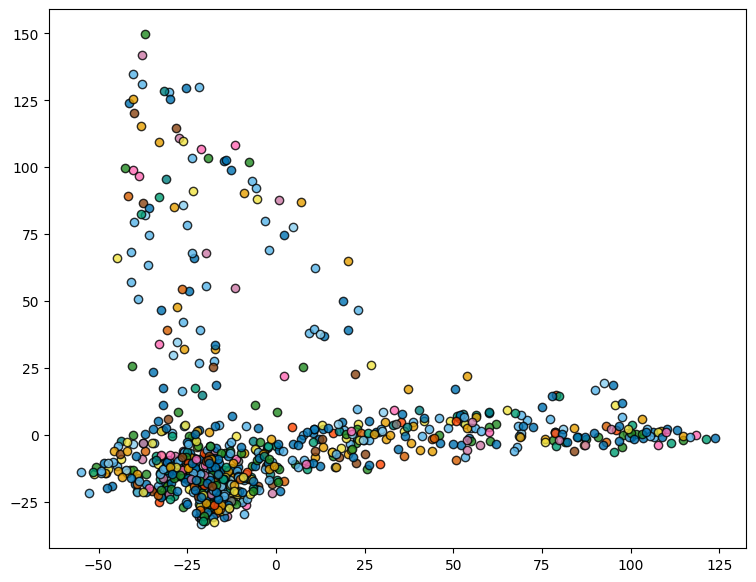

In [31]:

# Align genotypes directly to colors using widiv_labels_gen
var_exp = pca_genetic.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))

for i, label in enumerate(widiv_labels_gen):
    color = widiv_label_color_dict_gen.get(label, "grey")  # fallback color if label missing
    plt.scatter(pcs[i, 0], pcs[i, 1],
                c=color, edgecolors='k', label=label, alpha=0.8)

# Title and axes
plt.title('PCA of Gene Expression Data')
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.2f}% variance)')

# Legend (unique labels only)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove duplicates
plt.legend(by_label.values(), by_label.keys(),
           loc='best', bbox_to_anchor=(1.05, 1), title='Categories')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), title='Categories')

plt.tight_layout()
plt.show()


In [32]:
geno_df = pd.read_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/numeric_gt_table_34k.txt", sep="\t", index_col=0)
# Now df shape is (n_variants, n_samples)
geno = geno_df.values  # numpy array of shape (n_variants, n_samples)

IndexError: index 798 is out of bounds for axis 0 with size 798

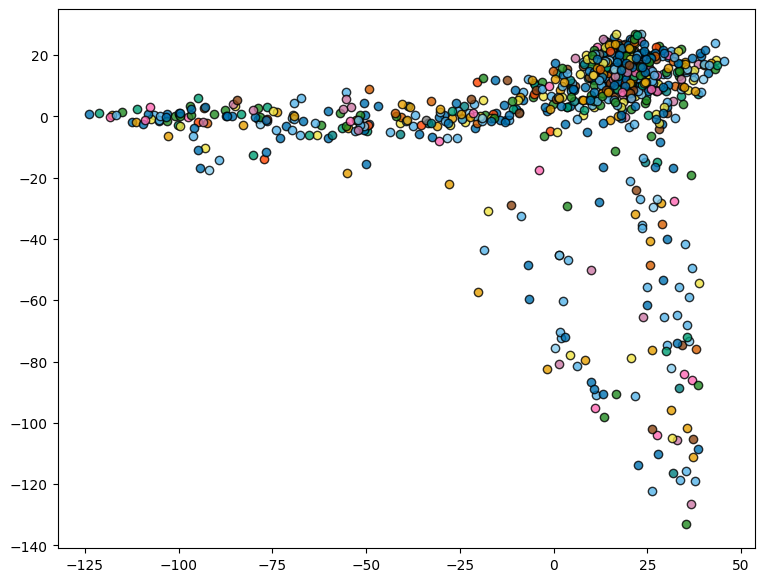

In [ ]:
# 3. Transpose to variants × samples (required by scikit-allel)
gn = geno.T

# 4. Handle missing values (if any NaNs)
if np.isnan(gn).any():
    # replace NaN with variant mean
    means = np.nanmean(gn, axis=1, keepdims=True)
    gn = np.where(np.isnan(gn), means, gn)

# 5. Run PCA
coords, model = allel.pca(gn, n_components=2, scaler="patterson")

# Explained variance
var_exp = model.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))

# Plot each sample with its group color
for i, label in enumerate(widiv_labels_gen):
    color = widiv_label_color_dict_gen.get(label, "grey")
    plt.scatter(coords[i, 0], coords[i, 1],
                c=color, edgecolors='k', alpha=0.8, label=label)

# Titles and axis labels
plt.title('PCA of SNP Genotype Data')
plt.xlabel(f'PC1 ({var_exp[0]:.2f}% variance)')
plt.ylabel(f'PC2 ({var_exp[1]:.2f}% variance)')

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           loc='best', bbox_to_anchor=(1.05, 1), title='Categories')

plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig2_B.pdf")


In [34]:
### Now make a PCA of the pheno data

In [35]:
# read in pheno data

pheno = pd.read_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/phenomics_input.csv")

In [36]:
# set index as GeneID

pheno_index = pheno.set_index("GeneID")

In [37]:
scaler = StandardScaler()
pheno_scaled = scaler.fit_transform(pheno_index)

# Step 3: Compute the first 5 PCs
pca_pheno = PCA(n_components=2)
pheno_pcs = pca_genetic.fit_transform(pheno_scaled)

In [38]:
widiv_labels = widiv_labels[:pheno_pcs.shape[0]]

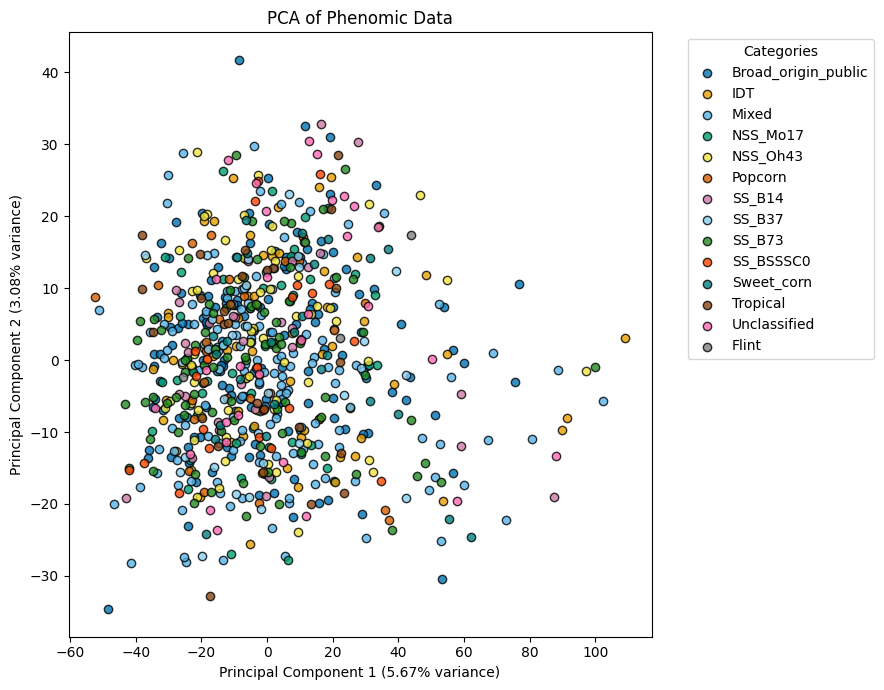

In [ ]:
# create a PCA with a legend

#var_exp = pca_pheno.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 7))
for label, color in widiv_label_color_dict.items():
    indices = [i for i, lbl in enumerate(widiv_labels) if lbl == label]
    plt.scatter(pheno_pcs[indices, 0], pheno_pcs[indices, 1],
                c=color, edgecolors='k', label=label, alpha=0.8)

# Add title and labels
plt.title('PCA of Phenomic Data')
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.2f}% variance)')

# Add legend
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), title='Categories')


# Adjust layout to fit legend
plt.tight_layout()

# Show the plot
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig2_C.pdf")

In [40]:
## Now do a similarity metric for each of the datasets

In [41]:
# read in all the datasets that have the correct genotype names

exp = pd.read_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/MI_NE_gene_expression.csv")
phen = pd.read_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/phenomics_input_names_altered.csv")

In [42]:
# set indices

exp_index = exp.set_index("GeneID")
phen_index = phen.set_index("GeneID")

In [43]:
print(exp_index.index)

Index(['A334_A334', 'A340_A340', 'A344_A344', 'A374_A374', 'A427_A427',
       'A508_A508', 'A554_A554', 'A556_A556', 'A572_A572', 'A619_A619',
       ...
       'WIL901_WIL901', 'WIL903_WIL903', 'WR3_WR3', 'WXB6_WXB6', 'Wf9_Wf9',
       'YE_4_YE_4', 'YING-55_YING-55', 'ZS01250_ZS01250', 'ZS1791_ZS1791',
       'ZS635_ZS635'],
      dtype='object', name='GeneID', length=577)


In [44]:
# now look at the intersection of all the indexes

# pairwise intersections
common_12 = genetic.index.intersection(exp_index.index)
common_13 = genetic.index.intersection(phen_index.index)
common_23 = exp_index.index.intersection(phen_index.index)

# align datasets pairwise
df1_12 = genetic.loc[common_12]
df2_12 = exp_index.loc[common_12]

df1_13 = genetic.loc[common_13]
df3_13 = phen_index.loc[common_13]

df2_23 = exp_index.loc[common_23]
df3_23 = phen_index.loc[common_23]


In [60]:
print(df2_23)

                 Zm00001eb000010  Zm00001eb000020  Zm00001eb000060  \
GeneID                                                               
A334_A334               3.480347         0.864924         3.959976   
A340_A340               2.894238         0.711874         2.617180   
A344_A344               3.727494         0.972644         4.628001   
A374_A374               2.973124         0.640502         2.571679   
A427_A427               3.413544         1.140491         4.272534   
...                          ...              ...              ...   
Wf9_Wf9                 3.141130         0.691922         3.909158   
YING-55_YING-55         3.142360         0.691028         3.920036   
ZS01250_ZS01250         3.878171         0.941866         4.583011   
ZS1791_ZS1791           3.266870         0.852758         3.961057   
ZS635_ZS635             2.818979         0.574260         3.870015   

                 Zm00001eb000070  Zm00001eb000080  Zm00001eb000120  \
GeneID             

In [68]:
common_genos = genetic.index.intersection(exp_index.index).intersection(phen_index.index)

df1_aligned = genetic.loc[common_genos]
df2_aligned = exp_index.loc[common_genos]
df3_aligned = phen_index.loc[common_genos]

In [71]:
# Transpose so rows are genotypes, columns are features
geno_corr_df1 = df1_aligned.T.corr()  # correlation between genotypes in df1
geno_corr_df2 = df2_aligned.T.corr()  # correlation between genotypes in df2
geno_corr_df3 = df3_aligned.T.corr()  # correlation between genotypes in df3


In [72]:
common_genos_12 = geno_corr_df1.index.intersection(geno_corr_df2.index)
common_genos_13 = geno_corr_df1.index.intersection(geno_corr_df3.index)
common_genos_23 = geno_corr_df2.index.intersection(geno_corr_df3.index)

# subset correlation matrices
corr1_12 = geno_corr_df1.loc[common_genos_12, common_genos_12]
corr2_12 = geno_corr_df2.loc[common_genos_12, common_genos_12]

corr1_13 = geno_corr_df1.loc[common_genos_13, common_genos_13]
corr3_13 = geno_corr_df3.loc[common_genos_13, common_genos_13]

corr2_23 = geno_corr_df2.loc[common_genos_23, common_genos_23]
corr3_23 = geno_corr_df3.loc[common_genos_23, common_genos_23]

In [73]:
def flatten_upper_tri(corr_matrix):
    # Only take the upper triangle, excluding diagonal
    iu = np.triu_indices_from(corr_matrix, k=1)
    return corr_matrix.values[iu]

flat_12_1 = flatten_upper_tri(corr1_12)
flat_12_2 = flatten_upper_tri(corr2_12)

flat_13_1 = flatten_upper_tri(corr1_13)
flat_13_3 = flatten_upper_tri(corr3_13)

flat_23_2 = flatten_upper_tri(corr2_23)
flat_23_3 = flatten_upper_tri(corr3_23)

In [74]:
corr_12 = np.corrcoef(flat_12_1, flat_12_2)[0, 1]
corr_13 = np.corrcoef(flat_13_1, flat_13_3)[0, 1]
corr_23 = np.corrcoef(flat_23_2, flat_23_3)[0, 1]

print("Correlation between genotype correlation matrices (PCC):")
print(f"df1 vs df2: {corr_12:.3f}")
print(f"df1 vs df3: {corr_13:.3f}")
print(f"df2 vs df3: {corr_23:.3f}")


Correlation between genotype correlation matrices (PCC):
df1 vs df2: 0.586
df1 vs df3: 0.052
df2 vs df3: 0.116


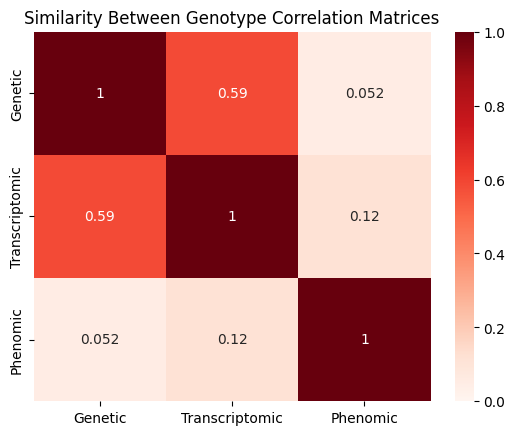

In [ ]:
sim_matrix = pd.DataFrame(
    [[1, corr_12, corr_13],
     [corr_12, 1, corr_23],
     [corr_13, corr_23, 1]],
    index=["Genetic", "Transcriptomic", "Phenomic"],
    columns=["Genetic", "Transcriptomic", "Phenomic"]
)

sns.heatmap(sim_matrix, annot=True, cmap="Reds", vmin=0, vmax=1)
plt.title("Similarity Between Genotype Correlation Matrices")
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig2_D.pdf")

In [ ]:
## Read in phenotype data

In [ ]:
# Beginning of reading in phenotype data

pheno_data = pd.read_csv('/Users/madisoncreach/Prediction_Project/pheno_data/Mural_2022/widiv_phenos.csv')

In [ ]:
# pull out the transformed gene expression by each state

MI_l2b = features_l2b_transposed.iloc[:725,:]
NE_l2b = features_l2b_transposed.iloc[725:,:]
print(MI_l2b.shape)
print(NE_l2b.shape)

(725, 28221)
(750, 28221)


In [ ]:
# special MI stuff to remove the numbers

MI_l2b.index = [name[5:] for name in MI_l2b.index]

In [ ]:
# Beginning of reading in phenotype data for new dataset

pheno_data_thompson = pd.read_csv('/Users/madisoncreach/Prediction_Project/pheno_data/Thompson/widiv2021pheno_4colorclasses_cleaned02272023.csv', header=0)
print(pheno_data_thompson.shape)

(761, 34)


In [ ]:
# set Genotype ID as the index for merging purposes and rename

pheno_new_index = pheno_data_thompson.set_index('common_name')
pheno_new_relabel = pheno_new_index.rename_axis('GeneID')
pheno_new_final = pheno_new_relabel.dropna()
print(pheno_new_final.shape)

(761, 33)


In [ ]:
# read in the phenotype data from the Mural paper

pheno_data_Mural = pd.read_csv('/Users/madisoncreach/Prediction_Project/pheno_data/Mural_2022/widiv_phenos_subset.csv')

In [ ]:
# rename and set the index column

pheno_index_Mural = pheno_data_Mural.set_index('GenotypeID')
pheno_relabel_Mural = pheno_index_Mural.rename_axis('GeneID')
print(pheno_relabel_Mural)

             SilkingGDD_L  AnthesisGDD_L  ASIGDD_L  Silking_L  Anthesis1_L  \
GeneID                                                                       
207                   NaN            NaN       NaN        NaN          NaN   
78004            1480.492       1501.790    32.372     71.827       67.512   
CML103           1357.680       1379.910    -5.161     81.147       80.077   
CML333           1415.942       1389.877    45.576     84.634       79.838   
CML341           1613.058       1525.075    59.264     93.534       86.618   
...                   ...            ...       ...        ...          ...   
YANG             1247.132       1241.975    58.746     62.091       58.502   
YE-CHI-HUNG      1419.214       1370.528    70.491     67.702       62.733   
YELLOW_3-4       1447.580       1414.809    21.928     69.021       63.951   
ZS1791                NaN            NaN       NaN        NaN          NaN   
DK3IIH6               NaN            NaN       NaN        NaN   

In [ ]:
# read in the phenotype data from the Thompson lab

pheno_data_Thompson = pd.read_csv('/Users/madisoncreach/Prediction_Project/pheno_data/Thompson/2021_widiv_processed_phenotypes_expr.csv')

In [ ]:
print(pheno_data_Thompson)

    PhenoName  EarHeightAvg  EarLeafNumberAvg  ExpLeaves1Avg  ExpLeaves2Avg  \
0       Oh40B         58.50             10.50           3.00           5.50   
1       PHHH9         44.75             13.25           4.25           5.75   
2     Sg_1533         95.75             15.25           5.00           7.00   
3         R78         71.75             12.25           3.00           5.50   
4         H84         47.25             11.50           3.75           6.50   
..        ...           ...               ...            ...            ...   
754   CML_322         72.75             16.75           3.75           6.00   
755      A649         28.50              9.00           4.00           6.00   
756     W818G         98.25             16.25           3.25           6.25   
757     PHP76         53.50             12.75           4.25           7.00   
758     CI_64         80.75             15.25           2.75           6.50   

     ExpLeaves3Avg  FlagHeightAvg  RootLodging  Sta

In [ ]:
# relabel and set index

pheno_Thompson_index = pheno_data_Thompson.set_index('PhenoName')
pheno_Thompson_relabel = pheno_Thompson_index.rename_axis('GeneID')
pheno_Thompson_final = pheno_Thompson_relabel.dropna()
print(pheno_Thompson_final.shape)

(693, 19)


In [ ]:
# merge both datasets with all phenotypes

full_phenos = pd.merge(pheno_relabel_Mural, pheno_Thompson_final, left_index=True, right_index=True)
print(full_phenos.shape)

(634, 181)


In [ ]:
# pull out all phenotypes to get SHAP values
phenotypes=[]
for i in full_phenos.columns:
    pheno_temp = full_phenos[[i]]
    phenotypes.append(i)

print(len(phenotypes))

181


In [ ]:
# randomly assign each of the genotypes to a fold holding 20%

num_folds = 5
folds = np.random.RandomState(seed=42).permutation(len(MI_l2b)) % num_folds
MI_l2b.loc[:,'fold'] = pd.Series(folds, index=MI_l2b.index)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_51569/2049279421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MI_l2b.loc[:,'fold'] = pd.Series(folds, index=MI_l2b.index)


In [ ]:
# assign each of the fold assignments from MI to NE

NE_l2b['fold'] = MI_l2b['fold']

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_51569/686919159.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NE_l2b['fold'] = MI_l2b['fold']


In [ ]:
# remove NAs from NE and make sure its type int

NE_l2b_drop = NE_l2b.dropna(subset=['fold'])

In [ ]:
# convert the fold column in NE from float to int

NE_l2b_drop['fold'] = NE_l2b_drop['fold'].astype(int)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_51569/2669856088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NE_l2b_drop['fold'] = NE_l2b_drop['fold'].astype(int)


In [ ]:
# save all processed dfs to inputs folder

#MI_l2b.to_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/MI_gene_expression.csv")
#NE_l2b_drop.to_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/NE_gene_expression.csv")

In [ ]:
# make a dataframe with the fold assignments for each genotype

MI_folds = MI_l2b['fold']

In [ ]:
# save these assignments to inputs folder

#MI_folds.to_csv("/Users/madisoncreach/Prediction_Project/Input_Datasets/fold_assignments.csv")